<a href="https://colab.research.google.com/github/Carmen10-171/04MIAR_Aprendizaje-Supervisado/blob/main/Actividad_Computer_Vision_C1_M%C2%AA_Carmen_Cop%C3%A9_Soler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Convocatoria 1 - Proyecto 1

In [3]:
import numpy as np
import matplotlib.pyplot as plt
!pip install scikit-image scipy opencv-python matplotlib pandas
import sys
!{sys.executable} -m pip install scikit-image

from skimage import io, color, filters, morphology, measure
from skimage import io

from skimage.filters import threshold_otsu
from skimage.segmentation import flood
from scipy.ndimage import binary_fill_holes
from scipy.spatial.distance import pdist
import cv2

#### 0) Cargar una de las imágenes histológicas

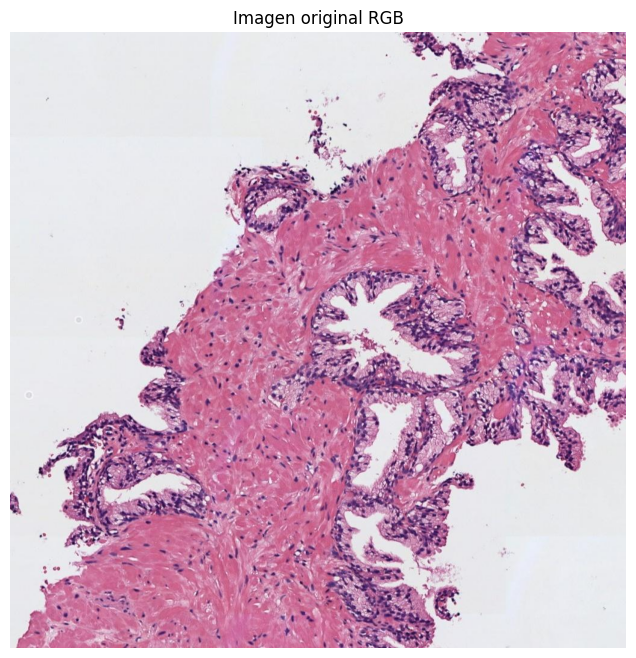

In [4]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
# Visualizar la imagen

# Cargar imagen
img = io.imread("histo_1.jpg")

# Normalizar

img = img.astype(np.float32) / 255.0

# Mostrar imagen

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title("Imagen original RGB")
plt.axis("off")
plt.show()


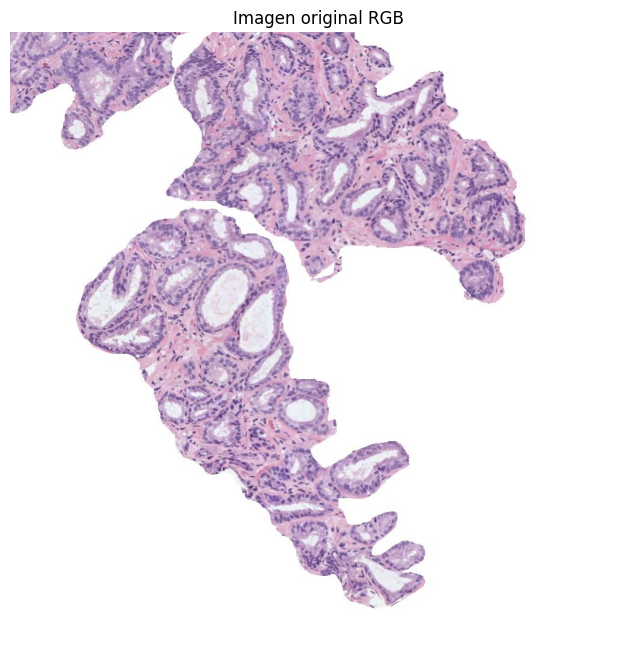

In [5]:
# Cargar imagen
img = io.imread("histo_2.jpg")

# Normalizar

img = img.astype(np.float32) / 255.0

# Mostrar imagen

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title("Imagen original RGB")
plt.axis("off")
plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

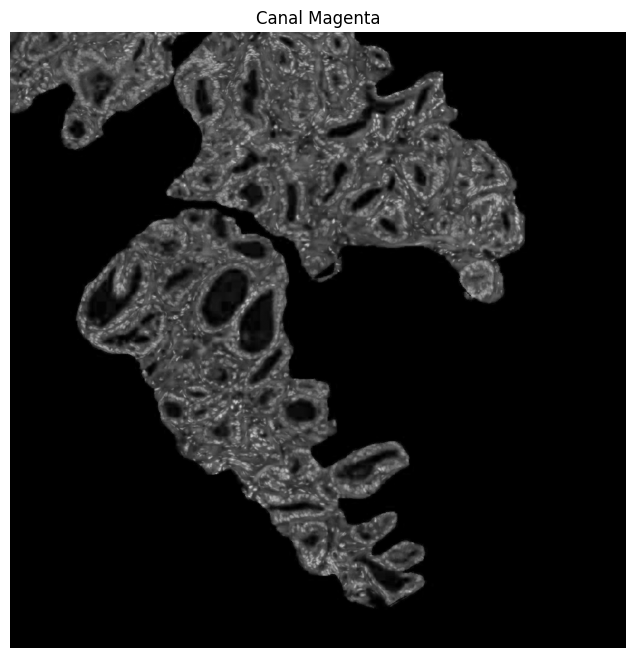

In [6]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta

R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]

K = 1 - np.max(img, axis=2)

C = (1 - R - K) / (1 - K + 1e-8)
M = (1 - G - K) / (1 - K + 1e-8)
Y = (1 - B - K) / (1 - K + 1e-8)

M = np.clip(M, 0, 1)

plt.figure(figsize=(8,8))
plt.imshow(M, cmap='gray')
plt.title("Canal Magenta")
plt.axis("off")
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

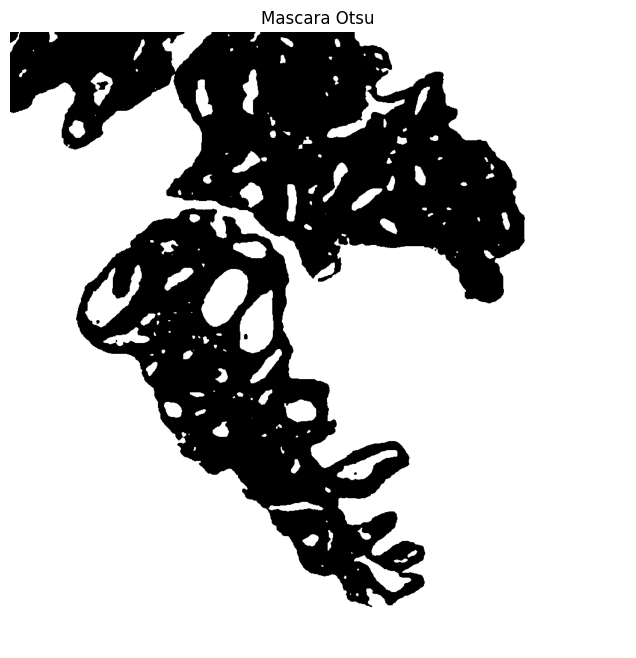

In [7]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante
M_blur = cv2.GaussianBlur(M, (5,5), 0)

M_uint8 = (M_blur * 255).astype(np.uint8)

th = threshold_otsu(M_uint8)

mask = M_uint8 < th

plt.figure(figsize=(8,8))
plt.imshow(mask, cmap='gray')
plt.title("Mascara Otsu")
plt.axis("off")
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

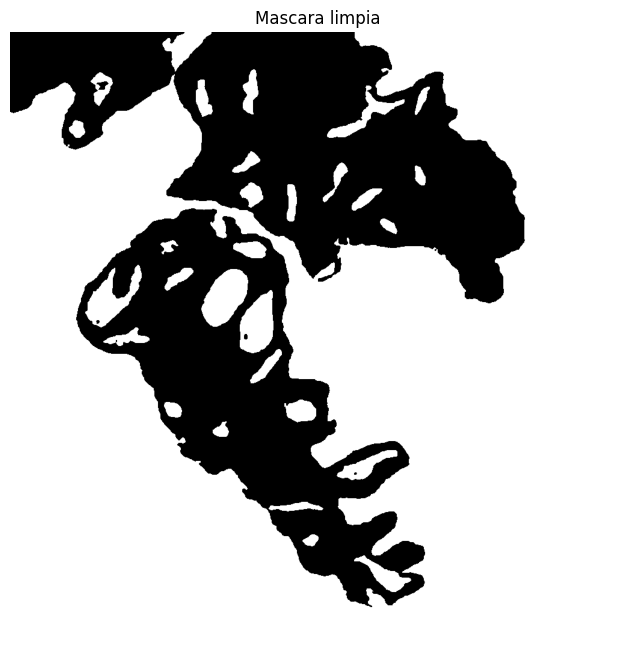

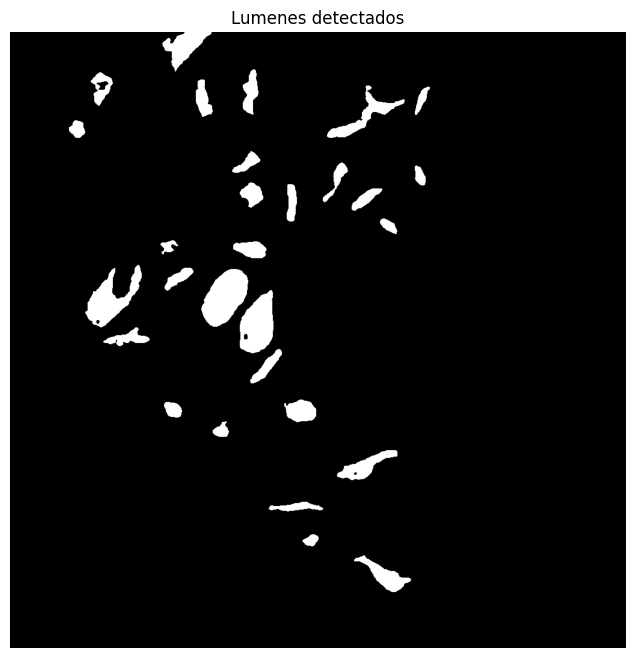

In [8]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante

# Eliminar objetos pequeños

mask_clean = morphology.remove_small_objects(
    mask.astype(bool),
    min_size=300
)

plt.figure(figsize=(8,8))
plt.imshow(mask_clean, cmap='gray')
plt.title("Mascara limpia")
plt.axis("off")
plt.show()

# Region Growing

seed1 = (0, 0)

seed2 = (
    mask_clean.shape[0] - 1,
    mask_clean.shape[1] - 1
)

background1 = flood(mask_clean, seed1)
background2 = flood(mask_clean, seed2)

background = background1 | background2

lumens = mask_clean.copy()
lumens[background] = False

plt.figure(figsize=(8,8))
plt.imshow(lumens, cmap='gray')
plt.title("Lumenes detectados")
plt.axis("off")
plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

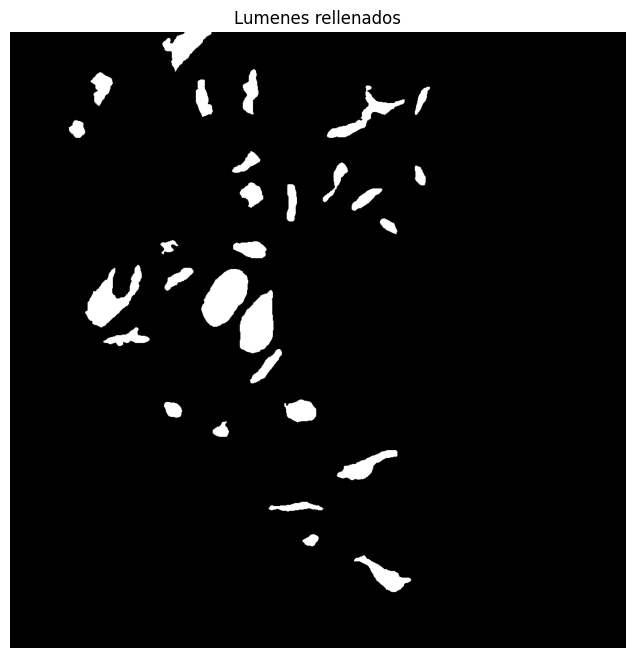

In [9]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante.

# Rellenar los lumenes

lumens_filled = binary_fill_holes(lumens)

# Mostrar resultado

plt.figure(figsize=(8,8))
plt.imshow(lumens_filled, cmap='gray')
plt.title("Lumenes rellenados")
plt.axis("off")
plt.show()

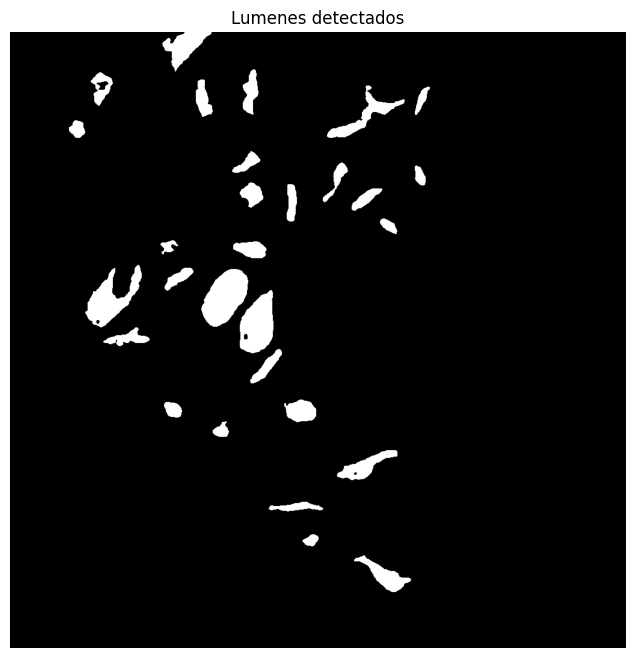

In [10]:
# ============================================================
# 4) REGION GROWING PARA ELIMINAR EL FONDO
# ============================================================
from skimage.segmentation import flood

seed1 = (0, 0)
seed2 = (0, mask_clean.shape[1]-1)
seed3 = (mask_clean.shape[0]-1, 0)
seed4 = (mask_clean.shape[0]-1, mask_clean.shape[1]-1)

bg1 = flood(mask_clean, seed1)
bg2 = flood(mask_clean, seed2)
bg3 = flood(mask_clean, seed3)
bg4 = flood(mask_clean, seed4)

background = bg1 | bg2 | bg3 | bg4

lumens = mask_clean.copy()
lumens[background] = False

plt.figure(figsize=(8,8))
plt.imshow(lumens, cmap='gray')
plt.title("Lumenes detectados")
plt.axis("off")
plt.show()

#### 5) Rellenar los objetos de los lúmenes

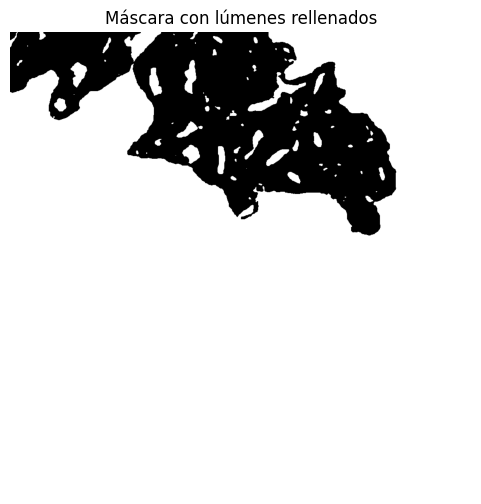

In [11]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

from scipy.ndimage import binary_fill_holes
import matplotlib.pyplot as plt

# Rellenar los huecos internos (lúmenes)
mask_rellena = binary_fill_holes(mask)

# Visualizar resultado
plt.figure(figsize=(6,6))
plt.imshow(mask_rellena, cmap='gray')
plt.title('Máscara con lúmenes rellenados')
plt.axis('off')
plt.show()

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

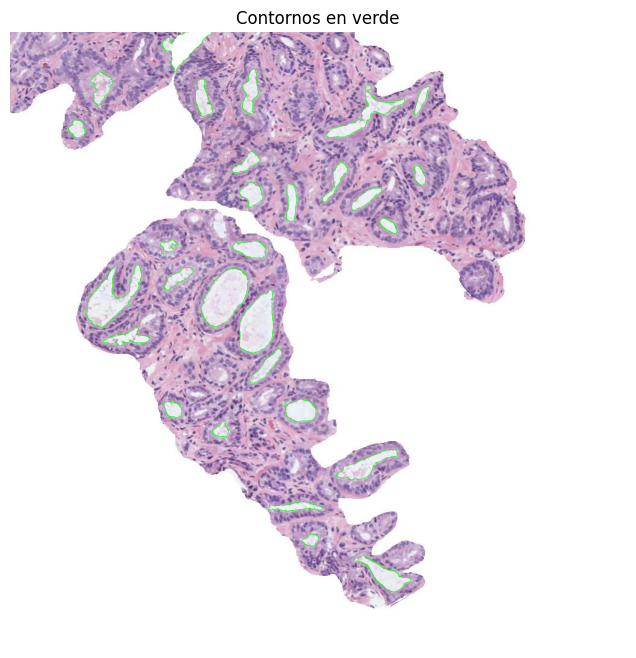

In [12]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles.
# Visualizar la imagen superpuesta

from skimage import measure
import matplotlib.pyplot as plt

# Encontrar contornos
contours = measure.find_contours(lumens_filled, level=0.5)

# Copia de la imagen original
overlay = img.copy()

# Dibujar contornos en verde
for contour in contours:

    contour = contour.astype(int)

    for r, c in contour:

        if 0 <= r < overlay.shape[0] and 0 <= c < overlay.shape[1]:
            overlay[r, c] = [0, 1, 0]

# Mostrar resultado
plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.title("Contornos en verde")
plt.axis("off")
plt.show()


#### 7) Identificar y cropear el lumen más grande

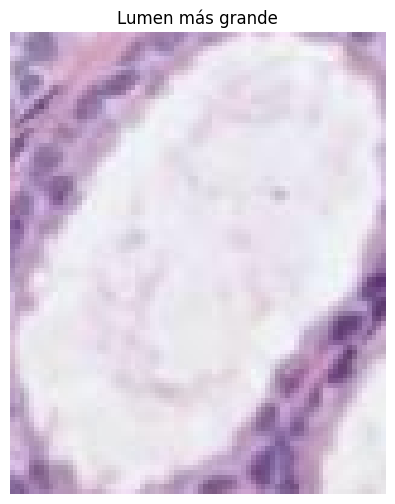

In [13]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

from skimage import measure
import matplotlib.pyplot as plt

# Etiquetar los lúmenes
labels = measure.label(lumens_filled)

# Obtener propiedades de las regiones
props = measure.regionprops(labels)

# Seleccionar el lumen de mayor área
largest = max(props, key=lambda x: x.area)

# Bounding box
minr, minc, maxr, maxc = largest.bbox

# Recorte de la imagen RGB
crop_rgb = img[minr:maxr, minc:maxc]

# Máscara recortada del lumen
crop_mask = (labels[minr:maxr, minc:maxc] == largest.label)

# Mostrar resultado
plt.figure(figsize=(6, 6))
plt.imshow(crop_rgb)
plt.title("Lumen más grande")
plt.axis("off")
plt.show()

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado

In [14]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad
import numpy as np

# Características de regionprops
area = round(largest.area, 4)

bbox_area = round(largest.area_bbox, 4) if hasattr(largest, 'area_bbox') else round(
    (largest.bbox[2] - largest.bbox[0]) *
    (largest.bbox[3] - largest.bbox[1]), 4)

convex_area = round(largest.convex_area, 4)

eccentricity = round(largest.eccentricity, 4)

equivalent_diameter = round(largest.equivalent_diameter, 4)

extent = round(largest.extent, 4)

# Diámetro Feret (si está disponible)
try:
    feret_diameter = round(largest.feret_diameter_max, 4)
except:
    feret_diameter = "No disponible"

major_axis_length = round(largest.axis_major_length, 4)

minor_axis_length = round(largest.axis_minor_length, 4)

orientation = round(largest.orientation, 4)

perimeter = round(largest.perimeter, 4)

solidity = round(largest.solidity, 4)

# Compacidad
compactness = round((4 * np.pi * area) / (perimeter ** 2), 4)

# Mostrar resultados
print("1. Área:", area)
print("2. Área Bounding Box:", bbox_area)
print("3. Área Convexa:", convex_area)
print("4. Excentricidad:", eccentricity)
print("5. Diámetro Equivalente:", equivalent_diameter)
print("6. Extensión:", extent)
print("7. Diámetro Feret:", feret_diameter)
print("8. Longitud Eje Mayor:", major_axis_length)
print("9. Longitud Eje Menor:", minor_axis_length)
print("10. Orientación:", orientation)
print("11. Perímetro:", perimeter)
print("12. Capacidad:", compactness)

print("\n===== CARACTERÍSTICAS GEOMÉTRICAS DEL LUMEN DE MAYOR ÁREA =====")
display(tabla_features.style.hide(axis='index'))

1. Área: 4855.0
2. Área Bounding Box: 7488.0
3. Área Convexa: 4988.0
4. Excentricidad: 0.8349
5. Diámetro Equivalente: 78.623
6. Extensión: 0.6484
7. Diámetro Feret: 105.5888
8. Longitud Eje Mayor: 106.201
9. Longitud Eje Menor: 58.453
10. Orientación: -0.5605
11. Perímetro: 279.8061
12. Capacidad: 0.7793

===== CARACTERÍSTICAS GEOMÉTRICAS DEL LUMEN DE MAYOR ÁREA =====


NameError: name 'tabla_features' is not defined

In [15]:
from scipy.spatial.distance import pdist
import numpy as np
from skimage import measure

prop = measure.regionprops(crop_mask.astype(np.uint8))[0]

# Área de la bounding box
minr, minc, maxr, maxc = prop.bbox
bbox_area = (maxr - minr) * (maxc - minc)

# Feret Diameter
coords = prop.coords

if len(coords) > 1:
    feret = np.max(pdist(coords))
else:
    feret = 0

# Compacidad
compactness = (4 * np.pi * prop.area) / (prop.perimeter ** 2 + 1e-8)

features = {
    "Area": round(prop.area, 4),
    "Bounding Box Area": round(bbox_area, 4),
    "Convex Area": round(prop.area_convex, 4),
    "Eccentricity": round(prop.eccentricity, 4),
    "Equivalent Diameter": round(prop.equivalent_diameter_area, 4),
    "Extent": round(prop.extent, 4),
    "Feret Diameter": round(float(feret), 4),
    "Major Axis Length": round(prop.axis_major_length, 4),
    "Minor Axis Length": round(prop.axis_minor_length, 4),
    "Orientation": round(prop.orientation, 4),
    "Perimeter": round(prop.perimeter, 4),
    "Solidity": round(prop.solidity, 4),
    "Compactness": round(compactness, 4)
}

print("===== CARACTERÍSTICAS =====\n")

for k, v in features.items():
    print(f"{k}: {v}")

===== CARACTERÍSTICAS =====

Area: 4855.0
Bounding Box Area: 7488
Convex Area: 4988.0
Eccentricity: 0.8349
Equivalent Diameter: 78.623
Extent: 0.6484
Feret Diameter: 103.9423
Major Axis Length: 106.201
Minor Axis Length: 58.453
Orientation: -0.5605
Perimeter: 279.8061
Solidity: 0.9733
Compactness: 0.7793


In [16]:
import pandas as pd
from IPython.display import display

tabla_features = pd.DataFrame({
    "Nº": range(1, 14),
    "Característica": [
        "Área",
        "Área Bounding Box",
        "Área Convexa",
        "Excentricidad",
        "Diámetro Equivalente",
        "Extensión",
        "Diámetro Feret",
        "Longitud Eje Mayor",
        "Longitud Eje Menor",
        "Orientación",
        "Perímetro",
        "Solidez",
        "Compacidad"
    ],
    "Valor": list(features.values())
})

display(tabla_features)

,Nº,Característica,Valor
0,1,Área,4855.0000
1,2,Área Bounding Box,7488.0000
2,3,Área Convexa,4988.0000
3,4,Excentricidad,0.8349
4,5,Diámetro Equivalente,78.6230
5,6,Extensión,0.6484
6,7,Diámetro Feret,103.9423
7,8,Longitud Eje Mayor,106.2010
8,9,Longitud Eje Menor,58.4530
9,10,Orientación,-0.5605


In [17]:
print("\n===== CARACTERÍSTICAS GEOMÉTRICAS DEL LUMEN DE MAYOR ÁREA =====")
display(tabla_features.style.hide(axis='index'))


===== CARACTERÍSTICAS GEOMÉTRICAS DEL LUMEN DE MAYOR ÁREA =====


Nº,Característica,Valor
1,Área,4855.000000
2,Área Bounding Box,7488.000000
3,Área Convexa,4988.000000
4,Excentricidad,0.834900
5,Diámetro Equivalente,78.623000
6,Extensión,0.648400
7,Diámetro Feret,103.942300
8,Longitud Eje Mayor,106.201000
9,Longitud Eje Menor,58.453000
10,Orientación,-0.560500
